In [2]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
import warnings 

warnings.filterwarnings("ignore")

In [3]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import AllChem
import numpy as np
import pickle
from tqdm import tqdm
from matplotlib import pyplot as plt
import os, glob, shutil
from DFTStructureGenerator import logfile_process, B_N_Cl, Tool, FormatConverter

In [4]:
# BN_df = pd.read_csv('Data/All_Data/reactants_B_N_passed.csv')
# Cl_df = pd.read_csv('Data/All_Data/reactants_Cl_passed.csv')
BN_df = pd.read_csv('Data/All_Data/reactants_B_N_old.csv')
Cl_df = pd.read_csv('Data/All_Data/reactants_Cl_old.csv')
B_smiles = list(set(BN_df['B_smiles'].to_list()))
N_smiles = list(set(BN_df['N_smiles'].to_list()))
Cl_smiles = list(set(Cl_df['Smiles'].to_list()))
B_mols = [Chem.MolFromSmiles(smi) for smi in B_smiles]
N_mols = [Chem.MolFromSmiles(smi) for smi in N_smiles]
Cl_mols = [Chem.MolFromSmiles(smi) for smi in Cl_smiles]
# B_fps = np.array([np.array(AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=2048)) for mol in B_mols])
# N_fps = np.array([np.array(AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=2048)) for mol in N_mols])
# Cl_fps = np.array([np.array(AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=2048)) for mol in Cl_mols])
# B_mfps = B_fps @ B_fps.T
# N_mfps = N_fps @ N_fps.T
# Cl_mfps = Cl_fps @ Cl_fps.T
target_idx = np.array(np.meshgrid(np.arange(len(BN_df['B_Index'])), np.arange(len(Cl_df['Smiles'])))).T.reshape(-1, 2)
# target_idx = [each for each in target_idx if (627.5 * (BN_df['deltaG_react'][each[0]] + Cl_df['deltaG_react'][each[1]]) < -4.1)]
len(target_idx)

3581790

In [ ]:
xbs = np.array([B_smiles.index(BN_df['B_smiles'][each[0]]) for each in target_idx])
xns = np.array([N_smiles.index(BN_df['N_smiles'][each[0]]) for each in target_idx])
xcs = np.array([Cl_smiles.index(Cl_df['Smiles'][each[1]]) for each in target_idx])

# 看看结构

In [9]:
len(B_mols), len(N_mols), len(Cl_mols)
# Chem.Draw.MolsToGridImage(B_mols, molsPerRow=7, useSVG=True)
# Chem.Draw.MolsToGridImage(N_mols, molsPerRow=7, useSVG=True)
# Chem.Draw.MolsToGridImage(Cl_mols, molsPerRow=7, useSVG=True)

(55, 386, 179)

In [13]:
num_substit = [0,0,0]
for B_mol in B_mols:
    B_atom = [each for each in B_mol.GetAtoms() if each.GetSymbol() == "B"][0]
    neighbors = len(B_atom.GetNeighbors())
    num_substit[neighbors] += 1
num_substit

[1, 30, 24]

In [ ]:
Anime_Nu = np.arange(0,69)
Phosphine_Nu = np.arange(69, 144)
NHC_Nu = np.arange(144, 224)
NHCS_Nu = np.arange(224, 234)
Ar_Nu = np.arange(234, 388)
N_Indexs = list(set(BN_df['N_Index'].to_list()))
print([each for each in np.arange(388) if each not in N_Indexs])
len(Anime_Nu), len(Phosphine_Nu), len(NHC_Nu), len(NHCS_Nu) - 1, len(Ar_Nu) - 1

[224, 327]


(69, 75, 80, 9, 153)

In [38]:
num_substit = [0,0,0,0]
num_substit_ = [0,0,0,0]
for Cl_mol in Cl_mols:
    Cl_mol = Chem.AddHs(Cl_mol)
    Cl_Atom = [each for each in Cl_mol.GetAtoms() if each.GetSymbol() == "Cl"][0]
    C_Atom = [atom for atom in Cl_Atom.GetNeighbors() if atom.GetSymbol() == "C"][0]
    neighbors = len([each for each in C_Atom.GetNeighbors() if each.GetSymbol() == 'Cl'])
    num_substit[neighbors - 1] += 1
    num_substit_[len(C_Atom.GetNeighbors()) - 1] += 1
num_substit, num_substit_

([102, 40, 36, 1], [0, 0, 21, 158])

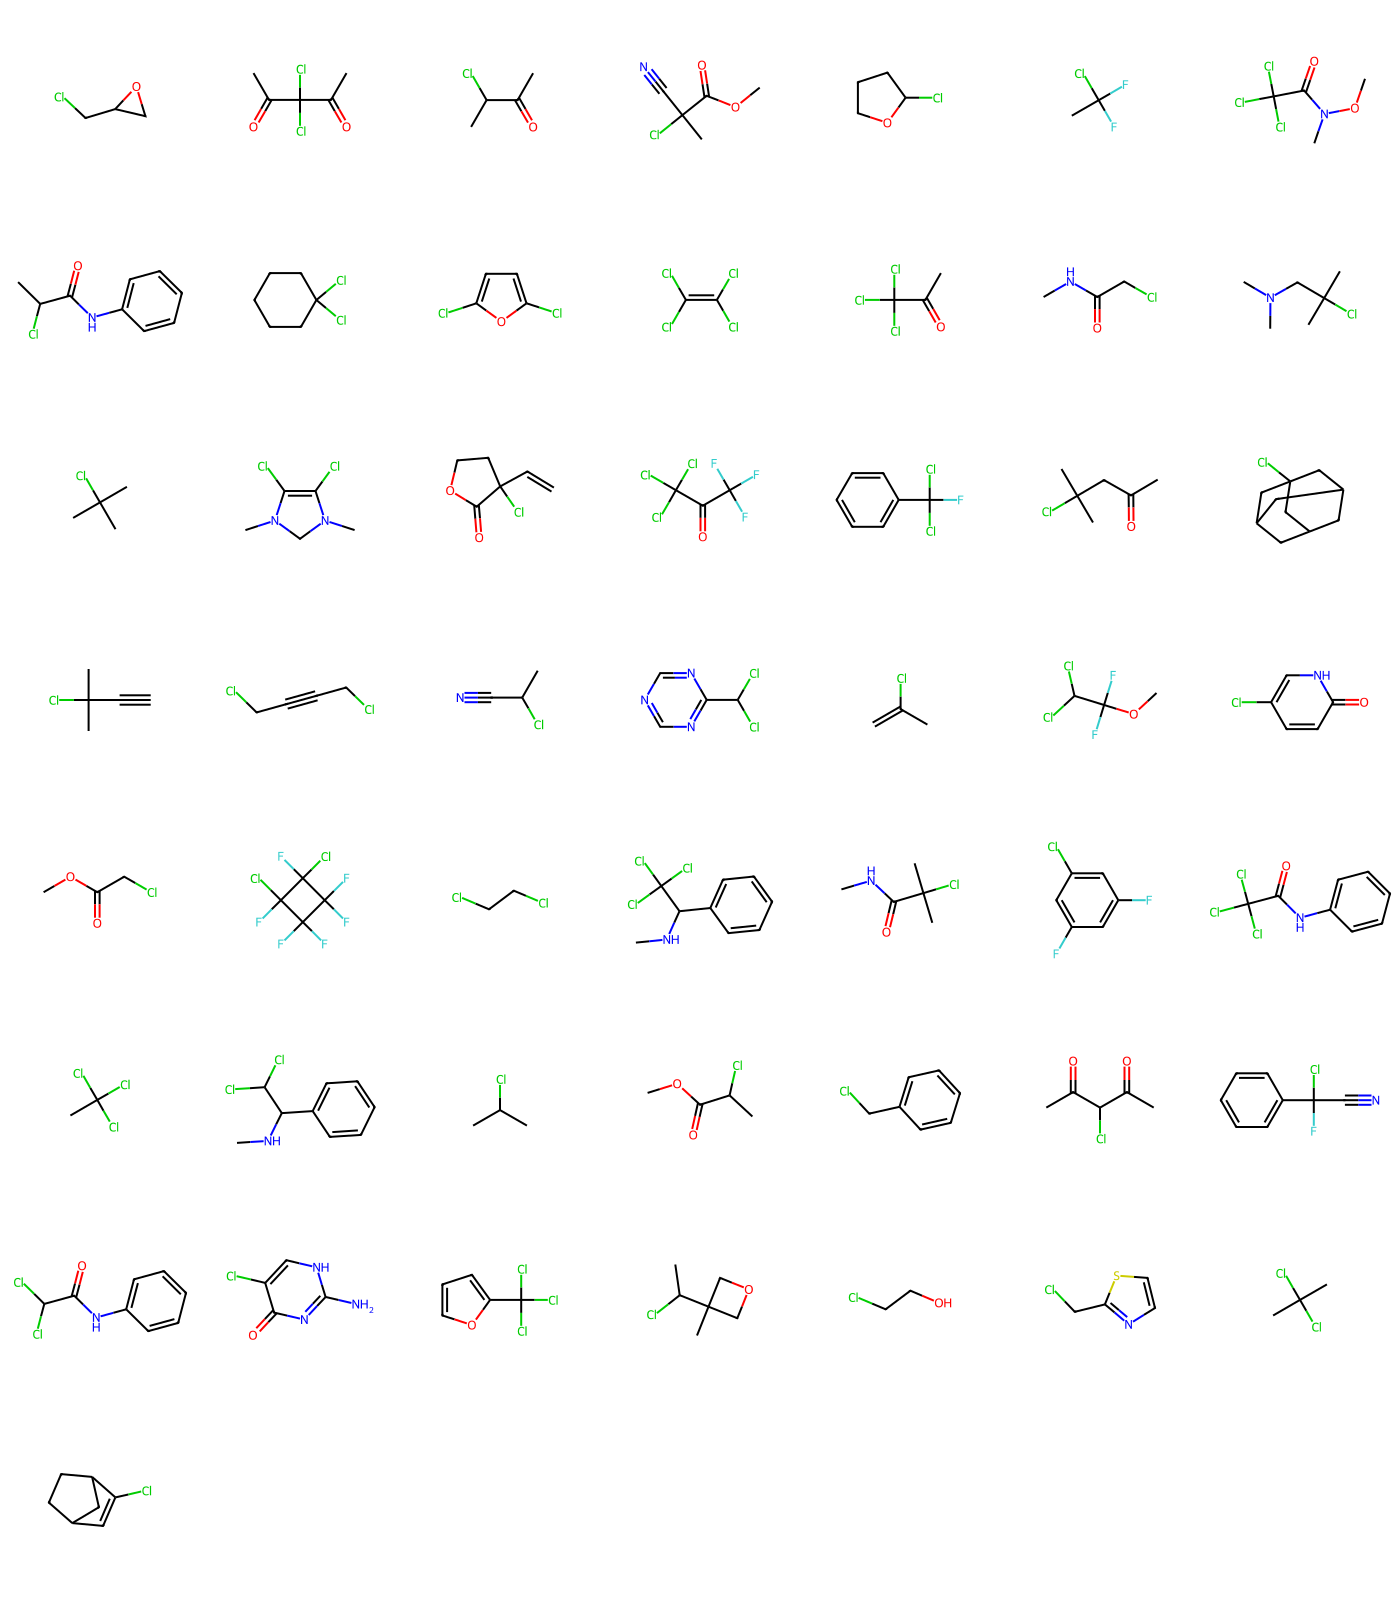

In [36]:
Chem.Draw.MolsToGridImage(Cl_mols[:50], molsPerRow=7, useSVG=True)

# 找到最接近中间的组合

In [ ]:
with open("Data/All_Data/BNdes_.pkl", 'rb') as f:
    B_N_des_map = pickle.load(f)
with open("Data/All_Data/Cldes_.pkl", 'rb') as f:
    Cl_des_map = pickle.load(f)

In [ ]:
final_array = []
for id_, each_idx in tqdm(enumerate(target_idx)):
    BN_row = BN_df.iloc[each_idx[0]]
    Cl_row = Cl_df.iloc[each_idx[1]]
    B_N_des = B_N_des_map[f'B_{BN_row["B_Index"]:05}_Nu_{BN_row["N_Index"]:05}']
    Cl_des = Cl_des_map[f'Cl_{Cl_row["Index"]:05}']
    sum_des = B_N_des +  Cl_des
    sum_des.append((sum_des[1] + sum_des[49]) * 627.5)
    temp_array = np.array(sum_des)[[87, 1, 4, 52, 53, 66, 8, 6, 76, 27, 79, 31, 10, 69]]
    final_array.append(temp_array.tolist())

# mean_array = np.mean(final_array, axis=0)
# distances = np.sqrt(np.sum((final_array - mean_array) ** 2, axis=1))
# zero_point_data = np.argmin(distances)
# print(B_smiles[xbs[zero_point_data]], N_smiles[xns[zero_point_data]], Cl_smiles[xcs[zero_point_data]])

In [38]:
def calc_distribution2(y, eachsize=0.01, title=None, xlab=None, ylab="Count", y_max=None, y_min=None):
    if y_max == None:    y_max = np.max(y)
    if y_min == None:    y_min = np.min(y)
    X = np.arange(y_min, y_max + eachsize, eachsize)
    des = [0 for each in X]
    z = (y - y_min)/eachsize
    for each in z:
        try:
            des[int(each)] += 1
        except:
            continue
    des = np.array(des)
    # des = des / len(y)
    
    fig = plt.figure(figsize=(4,3))
    ax = fig.add_subplot(111)
    ax.patch.set_alpha(0.0)
    plt.bar(X, des, width=eachsize/2, color="green")
    plt.xlim(y_min - eachsize, y_max + eachsize)
    plt.ylim(0, np.max(des) * 1.2)
    plt.xlabel(xlab, fontsize=30)
    plt.ylabel(ylab, fontsize=30)
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)
    if title != None:
        plt.title = title
    plt.tight_layout()
    plt.savefig('test.svg', format='svg')
    plt.show()
    return des

In [ ]:
calc_distribution2(distances, 1)

In [ ]:
distances[198]

# 基于最简单反应物的查找

In [ ]:
min_B_smiles = min(B_smiles, key=lambda x: Chem.MolFromSmiles(x).GetNumAtoms())
min_N_smiles = min(N_smiles, key=lambda x: Chem.MolFromSmiles(x).GetNumAtoms())
min_Cl_smiles = min(Cl_smiles, key=lambda x: Chem.MolFromSmiles(x).GetNumAtoms())
print(min_B_smiles, min_N_smiles, min_Cl_smiles)
for id, (BN, Cl) in enumerate(target_idx):
    if BN_df['B_smiles'][BN] == min_B_smiles and BN_df['N_smiles'][BN] == min_N_smiles and Cl_df['Smiles'][Cl] == min_Cl_smiles:
        zero_point_data = id
        break

In [ ]:
zero_point_data

In [ ]:
zero_point_data = 198
first_select_data = []
for id_, each_idx in tqdm(enumerate(target_idx)):
    if sum([xbs[id_] == xbs[zero_point_data], xns[id_] == xns[zero_point_data], xcs[id_] == xcs[zero_point_data]]) == 2:
        first_select_data.append(id_)
target_idx_ = [each for id_, each in enumerate(target_idx) if id_ not in first_select_data]
transfer_id = [id_ for id_, each in enumerate(target_idx) if id_ not in first_select_data]

In [ ]:
len(first_select_data)

In [ ]:
def generate_similarity(xb, xn, xc, yb, yn, yc):
    k = B_mfps[xb][yb] + N_mfps[xn, yn] + Cl_mfps[xc, yc]
    return k / (B_mfps[xb][xb] + N_mfps[xn, xn] + Cl_mfps[xc, xc] + B_mfps[yb][yb] + N_mfps[yn, yn] + Cl_mfps[yc, yc] - k)

final_array = []
for id_, each_idx in tqdm(enumerate(target_idx_)):
    BN_row = BN_df.iloc[each_idx[0]]
    Cl_row = Cl_df.iloc[each_idx[1]]
    B_N_des = B_N_des_map[f'B_{BN_row["B_Index"]:05}_Nu_{BN_row["N_Index"]:05}']
    Cl_des = Cl_des_map[f'Cl_{Cl_row["Index"]:05}']
    sum_des = B_N_des +  Cl_des
    sum_des.append((sum_des[1] + sum_des[49]) * 627.5)
    temp_array = np.array(sum_des)[[87, 1, 4, 52, 53, 66, 8, 6, 76, 27, 79, 31, 10, 69]]
    similarity = generate_similarity(xbs[id_], xns[id_], xcs[id_], xbs[zero_point_data], xns[zero_point_data], xcs[zero_point_data])
    temp_array = np.append(temp_array, similarity)
    final_array.append(temp_array.tolist())
    # final_array.append([BN_row["B_Index"], BN_row["N_Index"], Cl_row["Index"]])
    # if id_ >= 10:
    #     break
    # final_array = np.concatenate((final_array, sum_des)) if final_array.size else sum_des

'deltaG' 'B_N react deltaG' 'B_N B_spin' 'C_Cl Cl_Hirshfield_charge' 'C_Cl C_Hirshfield_charge'
'C_Cl C_Cl_dist', 'B_N B_N_dist', 'B_N B_Hirshfield_charge', 'C C_spin', 'B_N_Cl N_Cl_dist'
'C Alpha-HOMO', 'B_N_Cl LUMO', 'B_N Alpha-HOMO', 'C_Cl LUMO'

In [ ]:
import warnings
import numpy as np
from FADS import FADS

# 初始化FADS（可选tune_params=True自动调参，但增加时间）
fastds = FADS(np.array(final_array), tune_params=False)

# 忽略警告（GMM可能发出收敛警告）
# with warnings.catch_warnings():
#     warnings.simplefilter("ignore")
    # 无替换采样，选1万子集
subset_indices = fastds.DS(50000 - len(first_select_data))


In [ ]:
transfer_subset_indices = first_select_data + np.array(transfer_id)[subset_indices].tolist()


In [ ]:
len(set(xbs[transfer_subset_indices])), len(set(xns[transfer_subset_indices])), len(set(xcs[transfer_subset_indices]))

In [ ]:
len(set(xbs)), len(set(xns)), len(set(xcs))

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 示例数组，你可以替换成自己的数组
array = xns[transfer_subset_indices][:10000]

# 统计每个数的频率
unique_values, counts = np.unique(array, return_counts=True)
print(np.min(counts))
# 打印频率
# print("Unique values and their frequencies:")
# for value, count in zip(unique_values, counts):
#     print(f"{value}: {count}")

# 绘制直方图（使用条形图，因为是离散值）
plt.bar(unique_values, counts, color='skyblue')
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.title('Histogram of Array Frequencies')
plt.show()

In [ ]:
np.save('Data/Dataset/Iter_50000.npy', transfer_subset_indices)

In [ ]:
def pick_target(picker_idx, name='first_ts'):
    first_ts = {"B_smiles":{}, "B_Index":{}, "B_Atomid":{}, "N_smiles":{}, "N_Index":{}, "N_Atomid":{}, "Cl_smiles":{}, "Cl_Index":{}, 
    "Cl_Atomid":{}, "B_N_Cl_conf":{}, "Cl_r_conf":{}, "deltaG_react":{}, "G_energy":{}}
    first_ts_idx = 0
    for target_idx_id in picker_idx:
        B_N_idx, cl_atom_idx = target_idx[target_idx_id]
        first_ts["B_smiles"][first_ts_idx] = BN_df['B_smiles'][B_N_idx]
        first_ts["B_Index"][first_ts_idx] = BN_df['B_Index'][B_N_idx]
        first_ts["B_Atomid"][first_ts_idx] = BN_df['B_Atomid'][B_N_idx]
        first_ts["N_smiles"][first_ts_idx] = BN_df['N_smiles'][B_N_idx]
        first_ts["N_Index"][first_ts_idx] = BN_df['N_Index'][B_N_idx]
        first_ts["N_Atomid"][first_ts_idx] = BN_df['N_Atomid'][B_N_idx]
        first_ts["Cl_smiles"][first_ts_idx] = Cl_df['Smiles'][cl_atom_idx]
        first_ts["Cl_Index"][first_ts_idx] = Cl_df['Index'][cl_atom_idx]
        first_ts["Cl_Atomid"][first_ts_idx] = Cl_df['Atomid'][cl_atom_idx]
        first_ts["B_N_Cl_conf"][first_ts_idx] = BN_df['conf_idxs_p'][B_N_idx]
        first_ts["Cl_r_conf"][first_ts_idx] = Cl_df['conf_idxs_r'][cl_atom_idx]
        first_ts["deltaG_react"][first_ts_idx] = 627.5 * (BN_df['deltaG_react'][B_N_idx] + Cl_df['deltaG_react'][cl_atom_idx])
        first_ts["G_energy"][first_ts_idx] = BN_df['G_energy_r'][B_N_idx] + Cl_df['G_energy_r'][cl_atom_idx]

        first_ts_idx += 1
    first_df = pd.DataFrame(first_ts)
    first_df.to_csv(f'Data/Dataset/{name}.csv', index=False)

In [ ]:
pick_target(transfer_subset_indices[:10000], 'first_10000')

In [ ]:
# result_ = [f"{BN_df['B_Index'][each[0]]}_{BN_df['N_Index'][each[0]]}_{Cl_df['Index'][each[1]]}" for each in target_idx]
already_dataset = [pd.read_csv('Data/backup/64_sum.csv'), pd.read_csv("Data/Iteration_Data/30_sum.csv")]
# already_dataset = [pd.read_csv("Data/Iteration_Data/first_ts.csv")]
result_old = []
for each in already_dataset:
    result_old += [f"{each['B_Index'][id]}_{each['N_Index'][id]}_{each['Cl_Index'][id]}" for id in range(len(each))]
old_picker = []
for each in transfer_subset_indices[:10000]:
    B_N_idx, cl_atom_idx = target_idx[each]
    if f"{BN_df['B_Index'][B_N_idx]}_{BN_df['N_Index'][B_N_idx]}_{Cl_df['Index'][cl_atom_idx]}" in result_old:
        old_picker.append(each)

# 汇总所有结构信息

In [ ]:
import glob
from DFTStructureGenerator import logfile_process, Tool

In [ ]:
duplicate_N_id = [9, 43, 285, 310, 314, 345, 346, 347, 348, 349, 350, 351, 352, 353, 354, 355, 356, 357, 358, 359, 360, 361, 362, 372, 375, 376]
duplicate_Cl_id = [624, 625, 626, 627, 628, 629, 630, 631, 632, 633, 634, 635, 636,
       637, 638, 639, 640, 642, 644, 645, 652, 653, 654, 655, 656, 657, 658, 659, 660, 661, 662, 663, 664,
       665, 666, 667, 668, 669, 670, 671, 672, 673, 674, 675, 676, 677,
       678, 679, 680, 681, 682, 683, 684, 685, 686, 687, 688, 689, 690,
       691, 692, 693, 694, 695, 696, 697, 698, 699, 700, 701, 702, 703,
       704, 705, 706, 707, 708, 709, 710, 711, 713, 714, 716, 717, 718, 719, 720, 721, 722]

In [ ]:
pre_csv = pd.read_csv("Data\Borane_all.csv")
new_csv_files = glob.glob("Data/Iteration_Data/pred*.csv") + glob.glob("Data/Iteration_Data/reactions*.csv") + glob.glob("Data/Iteration_Data/srtp*.csv") + glob.glob("Data/Iteration_Data/wellpred*.csv")
for each in new_csv_files:
    pre_csv = pre_csv._append(pd.read_csv(each))

In [ ]:
# pre_csv = pre_csv.drop(columns=['error_reason_ts', 'bond_1', 'bond_2', 'Pred_Value', 'Unnamed: 0', 'Condition', 'pred_value', 'AAM', 'B_Cl_bond', 'C_Cl_bond'])
pre_csv = pd.read_csv("Data/All_csv_14586.csv")
pre_csv = pre_csv.dropna()
pre_csv = pre_csv.drop_duplicates(['B_Index', 'N_Index', 'Cl_Index', 'Cl_Atomid'])

In [ ]:
all_logs = glob.glob(r"E:\work\B_Cl_Nu\Data\*\TS\*.log") + glob.glob(r"E:\work\B_Cl_Nu\backup\*\TS\*.log")
B_Cl_bond = []
C_Cl_bond = []
Angle = []
for row_id, row in pre_csv.iterrows():
    B_Index, N_Index, Cl_Index = int(row['B_Index']), int(row['N_Index']), int(row['Cl_Index'])
    B_Atomid, N_Atomid, Cl_Atomid = int(row['B_Atomid']), int(row['N_Atomid']), int(row['Cl_Atomid'])
    conf_id = int(row['conf_idxs_ts'])
    if conf_id == -1:
        mol_name = f"B_{B_Index:05}_Nu_{N_Index:05}_Cl_{Cl_Index:05}.log"
    elif Cl_Index in duplicate_Cl_id:
        mol_name = f"B_{B_Index:05}_Nu_{N_Index:05}_Cl_{Cl_Index:05}_Claid_{Cl_Atomid:05}_{conf_id:04}.log"
    else:
        mol_name = f"B_{B_Index:05}_Nu_{N_Index:05}_Cl_{Cl_Index:05}_{conf_id:04}.log"
    find_log = None
    for each_log in all_logs:
        if mol_name in each_log:
            find_log = each_log
            break
    if find_log == None:
        B_Cl_bond.append(np.nan)
        C_Cl_bond.append(np.nan)
        Angle.append(np.nan)
        continue
    target_log = logfile_process.Logfile(find_log)
    title = [each - 1 for each in target_log.title]
    if len(title) == 0:
        B_Cl_bond.append(np.nan)
        C_Cl_bond.append(np.nan)
        Angle.append(np.nan)
        continue
        B_num_atom = Chem.AddHs(Chem.MolFromSmiles(row['B_smiles'])).GetNumAtoms()
        N_num_atom = Chem.AddHs(Chem.MolFromSmiles(row['N_smiles'])).GetNumAtoms()
        B_index = target_log.symbol_list.index("B")
        Cl_index = target_log.symbol_list.index("Cl")
        # assert target_log.symbol_list[Cl_Atomid + B_num_atom + N_num_atom] == 'Cl'
        C_atom_id = Chem.MolFromSmiles(row['Cl_smiles']).GetAtomWithIdx(Cl_Atomid).GetNeighbors()[0].GetIdx()
        title = [B_index, Cl_index, C_atom_id + B_num_atom + N_num_atom]
    position = target_log.running_positions[-1]
    B_Cl_bond.append(Tool.get_atoms_distance(position[title[0]], position[title[1]]))
    C_Cl_bond.append(Tool.get_atoms_distance(position[title[2]], position[title[1]]))
    Angle.append(Tool.get_bond_angle(position[title[0]], position[title[1]], position[title[2]]))

In [ ]:
pre_csv['B_Cl_bond'] = B_Cl_bond
pre_csv['C_Cl_bond'] = C_Cl_bond
pre_csv['Angle'] = Angle
pre_csv = pre_csv.dropna()
pre_csv.to_csv(f"Data/All_csv_{len(pre_csv)}.csv", index=False)

In [ ]:
pre_csv.to_csv(f"Data/All_csv_{len(pre_csv)}.csv", index=False)

In [ ]:
len(pre_csv)

In [ ]:
np.min(pre_csv['B_Cl_bond']), np.max(pre_csv['B_Cl_bond']), np.min(pre_csv['C_Cl_bond']), np.max(pre_csv['C_Cl_bond'])

In [ ]:
np.mean(pre_csv['B_Cl_bond']), np.mean(pre_csv['C_Cl_bond'])

In [ ]:
data_csv = pre_csv

# data_csv = pd.read_csv(f"Data/All_csv_7643.csv")
y = data_csv['deltaGa']
target_eng = data_csv['deltaGa']
all_Xs = []
for line_id, line in tqdm(data_csv.iterrows()):
    B_Index = int(line['B_Index'])
    N_Index = int(line['N_Index'])
    Cl_Index = int(line['Cl_Index'])
    Cl_Atomid = int(line['Cl_Atomid'])
    B_N_name = f"B_{B_Index:05}_Nu_{N_Index:05}"
    Cl_name = f"Cl_{Cl_Index:05}"
    if Cl_Index in duplicate_Cl_id:
        Cl_name = f"Cl_{Cl_Index:05}_Claid_{Cl_Atomid:05}"
    des_a = B_N_des_map[B_N_name]
    des_b = Cl_des_map[Cl_name]
    all_Xs.append(des_a + des_b)
print(len(all_Xs))
all_Xs = np.array(all_Xs)
delta_G_r = 627.5*(all_Xs[:, 1] + all_Xs[:, 49])
all_Xs = np.hstack([all_Xs, delta_G_r.reshape(-1, 1)])

In [ ]:
np.save('Data/Dataset/9811_des.npy', all_Xs)

In [ ]:
from catboost import CatBoostRegressor
from sklearn.model_selection import cross_val_score, KFold

In [ ]:
model = CatBoostRegressor(iterations=10000, learning_rate=0.05, depth=6, verbose=0)
cross_val_score(model, all_Xs, data_csv['B_Cl_bond'], cv=KFold(n_splits=5, shuffle=True, random_state=0), scoring='r2')

In [ ]:
model = CatBoostRegressor(iterations=10000, learning_rate=0.05, depth=6, verbose=0)
cross_val_score(model, all_Xs, data_csv['C_Cl_bond'], cv=KFold(n_splits=5, shuffle=True, random_state=0), scoring='r2')

In [ ]:
model = CatBoostRegressor(iterations=10000, learning_rate=0.05, depth=6, verbose=0)
cross_val_score(model, all_Xs, data_csv['Angle'], cv=KFold(n_splits=5, shuffle=True, random_state=0), scoring='r2')

In [ ]:
model = CatBoostRegressor(iterations=10000, learning_rate=0.05, depth=6, verbose=0)
cross_val_score(model, all_Xs, data_csv['deltaGa'], cv=KFold(n_splits=5, shuffle=True, random_state=0), scoring='r2')

# 绘制代表性结构图

In [ ]:
transfer_subset_indices = np.load('Data/Dataset/Iter_50000.npy', )

In [ ]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
cut_off_id = 10000
ax.scatter(xbs[transfer_subset_indices[:cut_off_id]], xns[transfer_subset_indices[:cut_off_id]], xcs[transfer_subset_indices[:cut_off_id]], c='g', marker='o', s=5, alpha=0.5)


In [ ]:
plt.scatter(xbs[transfer_subset_indices[:cut_off_id]], xns[transfer_subset_indices[:cut_off_id]], marker=".", c='green', s=5)

In [ ]:
plt.scatter(xbs[transfer_subset_indices[:cut_off_id]], xcs[transfer_subset_indices[:cut_off_id]], marker=".", c='green', s=5)

In [ ]:
plt.scatter(xns[transfer_subset_indices[:cut_off_id]], xcs[transfer_subset_indices[:cut_off_id]], marker=".", c='green', s=5)

# 数据合并

In [ ]:
target_df=  pd.read_csv('Data/All_csv_14586.csv').dropna()
target_df = target_df.loc[target_df.groupby(['B_Index', 'N_Index', 'Cl_Index'])['deltaGa'].idxmin()].reset_index(drop=True)
# target_df.to_csv('Data/All_csv_14586.csv', index=False)
len(target_df)

In [ ]:
all_appear_dataset = []
new_df = pd.DataFrame()
for row_id, each in target_df.iterrows():
    all_appear_dataset.append(f"{each['B_Index']}_{each['N_Index']}_{each['Cl_Index']}")
for row_id, each in pd.read_csv("Data/Dataset/first_10000.csv").iterrows():
    if f"{each['B_Index']}_{each['N_Index']}_{each['Cl_Index']}" not in all_appear_dataset:
        new_df = new_df._append(each)
len(new_df)

In [ ]:
# 计算first_10000中各个B_Index的个数
B_count = []
for B_id in sorted(first_10000['B_Index'].unique().tolist()):
    B_count.append(len(first_10000[first_10000['B_Index'] == B_id]))
plt.plot(sorted(first_10000['B_Index'].unique().tolist()), B_count, c='g', marker='o')
print(np.sort(first_10000['B_Index'].unique())[np.argsort(B_count)])

In [ ]:
# 计算first_10000中各个N_Index的个数
N_count = []
for N_id in sorted(first_10000['N_Index'].unique().tolist()):
    N_count.append(len(first_10000[first_10000['N_Index'] == N_id]))
plt.plot(sorted(first_10000['N_Index'].unique().tolist()), N_count, c='g', marker='o')
print(np.sort(first_10000['N_Index'].unique())[np.argsort(N_count)])

# 汇集所有TS\TS_ENG\IRC，并保留原先与后续路径

In [46]:
BN_df = pd.read_csv('Data/All_Data/reactants_B_N_old.csv')
Cl_df = pd.read_csv('Data/All_Data/reactants_Cl_old.csv')
all_B_id = BN_df['B_Index'].unique().tolist()
all_N_id = BN_df['N_Index'].unique().tolist()
all_Cl_id = Cl_df['Index'].unique().tolist()
B_transform = {B_id:id_ for id_, B_id in enumerate(all_B_id)}
N_transform = {N_id:id_ for id_, N_id in enumerate(all_N_id)}
Cl_transform = {Cl_id:id_ for id_, Cl_id in enumerate(all_Cl_id)}
print(len(all_B_id), len(all_N_id), len(all_Cl_id))

55 386 179


In [ ]:
all_TS_files = glob.glob(r"E:\work\B_Cl_Nu\Data\*\TS\*.log") + glob.glob(r"E:\work\B_Cl_Nu\backup\*\TS\*.log")

In [ ]:
len(all_TS_files)

In [ ]:
avaliable_TS_files = []
for each_file in glob.glob(r"E:\work\B_Cl_Nu\Sum\TS_ENG\*.log"):
    B_id, N_id, Cl_id = [int(each) for each in os.path.basename(each_file).split('.')[0].split('_')[1:6:2]]
    if B_id in all_B_id and N_id in all_N_id and Cl_id in all_Cl_id:
        # avaliable_TS_files.append(each_file)
        avaliable_TS_files.append([B_id, N_id, Cl_id])
avaliable_TS_files = np.unique(np.array(avaliable_TS_files), axis=0)
print(len(avaliable_TS_files))

In [ ]:
all_success_bs = np.array([B_transform[each[0]] for each in avaliable_TS_files])
all_success_ns = np.array([N_transform[each[1]] for each in avaliable_TS_files])
all_success_cls = np.array([Cl_transform[each[2]] for each in avaliable_TS_files])
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(all_success_bs, all_success_ns, all_success_cls, c='orange', marker='o', s=5, alpha=0.5)
# 画出框线

plt.figure(figsize=(6,6))
plt.scatter(all_success_bs, all_success_ns, marker=".", c='orange', s=5, alpha=0.5)
plt.figure(figsize=(6,6))
plt.scatter(all_success_bs, all_success_cls, marker=".", c='orange', s=5, alpha=0.5)
plt.figure(figsize=(6,6))
plt.scatter(all_success_ns, all_success_cls, marker=".", c='orange', s=5, alpha=0.5)

In [ ]:
# 统计all_ts中各个B_Index的个数
B_count = []
for B_id in range(len(all_B_id)):
    B_count.append(len(all_success_bs[all_success_bs == B_id]))
print(np.min(B_count), np.max(B_count))
plt.plot(range(len(all_B_id)), B_count, c='g', marker='o')

In [ ]:
# 统计all_ts中各个N_Index的个数
N_count = []
for N_id in range(len(all_N_id)):
    N_count.append(len(all_success_ns[all_success_ns == N_id]))
print(np.min(N_count), np.max(N_count))
plt.plot(range(len(all_N_id)), N_count, c='g', marker='o')

In [ ]:
# 统计all_ts中各个Cl_Index的个数
Cl_count = []
for Cl_id in range(len(all_Cl_id)):
    Cl_count.append(len(all_success_cls[all_success_cls == Cl_id]))
print(np.min(Cl_count), np.max(Cl_count))
plt.plot(range(len(all_Cl_id)), Cl_count, c='g', marker='o')

In [ ]:
# 整理所有TS文件
old_new_path_df = pd.DataFrame(columns=['old_path', 'new_path'])
new_dir = r'E:\work\B_Cl_Nu\Sum\TS'
all_TS_files = glob.glob(r"E:\work\B_Cl_Nu\Data\*\TS\*.log") + glob.glob(r"E:\work\B_Cl_Nu\backup\*\TS\*.log")
for each_file in tqdm(all_TS_files):
    B_id, N_id, Cl_id = [int(each) for each in os.path.basename(each_file).split('.')[0].split('_')[1:6:2]]
    if B_id in all_B_id and N_id in all_N_id and Cl_id in all_Cl_id:
        new_path = os.path.join(new_dir, os.path.basename(each_file))
        old_new_path_df = old_new_path_df._append({'old_path':each_file, 'new_path':new_path}, ignore_index=True)
#         shutil.copy(each_file, new_path)
# old_new_path_df.to_csv(r'E:\work\B_Cl_Nu\Sum\All_TS_file_paths.csv', index=False)

In [ ]:
# 整理所有 TS_ENG 文件
old_new_path_df = pd.DataFrame(columns=['old_path', 'new_path'])
new_dir = r'E:\work\B_Cl_Nu\Sum\TS_ENG'
all_TS_ENG_files = glob.glob(r"E:\work\B_Cl_Nu\Data\*\TS_ENG\*.log") + glob.glob(r"E:\work\B_Cl_Nu\backup\*\TS_ENG\*.log")
for each_file in tqdm(all_TS_ENG_files):
    B_id, N_id, Cl_id = [int(each) for each in os.path.basename(each_file).split('.')[0].split('_')[1:6:2]]
    if B_id in all_B_id and N_id in all_N_id and Cl_id in all_Cl_id:
        new_path = os.path.join(new_dir, os.path.basename(each_file))
        old_new_path_df = old_new_path_df._append({'old_path':each_file, 'new_path':new_path}, ignore_index=True)
#         shutil.copy(each_file, new_path)
# old_new_path_df.to_csv(r'E:\work\B_Cl_Nu\Sum\All_TS_ENG_file_paths.csv', index=False)

In [ ]:
# 筛选没算出TS_ENG的TS文件
all_TS_files = glob.glob(r"E:\work\B_Cl_Nu\Sum\TS\*.log")
for each_file in all_TS_files:
    if not os.path.exists(each_file.replace('TS', 'TS_ENG')):
        shutil.move(each_file, each_file.replace('TS', 'TS_no_ENG'))


In [ ]:
SPE_METHOD = "wb97xd/6-311+g(d,p) scrf=(smd,solvent=toluene) Scf=xqc stable=opt nosymm"
from DFTStructureGenerator import B_N_Cl
target_dir = r'E:\work\B_Cl_Nu\Sum'
B_N_Cl.SPE_DFT_calc(target_dir, 'TS_no_ENG', 'TS_ENG_no_ENG', method=SPE_METHOD)

In [ ]:
# 整理所有 IRC 文件
old_new_path_df = pd.DataFrame(columns=['old_path', 'new_path'])
new_dir = r'E:\work\B_Cl_Nu\Sum\IRC'
all_IRC_files = glob.glob(r"E:\work\B_Cl_Nu\Data\*\IRC\*.log") + glob.glob(r"E:\work\B_Cl_Nu\backup\*\IRC\*.log")
for each_file in tqdm(all_IRC_files):
    base_name = os.path.basename(each_file).split('.')[0]
    B_id, N_id, Cl_id = [int(each) for each in os.path.basename(each_file).split('.')[0].replace("forward", "").replace('reverse', '').split('_')[1:6:2]]
    if B_id in all_B_id and N_id in all_N_id and Cl_id in all_Cl_id:
        if [B_id, N_id, Cl_id] in avaliable_TS_files.tolist():
            new_path = os.path.join(new_dir, os.path.basename(each_file))
            old_new_path_df = old_new_path_df._append({'old_path':each_file, 'new_path':new_path}, ignore_index=True)
            shutil.copy(each_file, new_path)
old_new_path_df.to_csv(r'E:\work\B_Cl_Nu\Sum\All_IRC_file_paths.csv', index=False)

In [ ]:
from DFTStructureGenerator import B_N_Cl
target_dir = r'E:\work\B_Cl_Nu\Sum'
B_N_Cl.reaction_calc_irc(target_dir=target_dir, ts_name="TS", irc_name='IRC_', require_all=True)

In [ ]:
# 删除重复的IRC
all_irc_files = glob.glob(r"E:\work\B_Cl_Nu\Sum\IRC_full\*.gjf")
for each_file in all_irc_files:
    if os.path.exists(each_file.replace('IRC_full', 'IRC').replace('.gjf', '.log')):
        os.remove(each_file)

In [ ]:
# 统计过渡态时间消耗
all_irc_files = glob.glob(r"E:\work\B_Cl_Nu\Sum\IRC\*.log")
time_15step, time_30step = [], []
for each_file in all_irc_files:
    try:
        log = logfile_process.Logfile(each_file)
        if 'maxpoints=30' in log.method:
            time_30step.append(log.running_time)
        else:
            time_15step.append(log.running_time)
    except:
        continue
    # break

In [ ]:
np.mean(time_15step), np.mean(time_30step)

In [ ]:
calced_TS_files = []
for each_file in glob.glob(r"E:\work\B_Cl_Nu\Sum\TS_needIRC_new\*.log"):
    B_id, N_id, Cl_id = [int(each) for each in os.path.basename(each_file).split('.')[0].split('_')[1:6:2]]
    if B_id in all_B_id and N_id in all_N_id and Cl_id in all_Cl_id:
        # avaliable_TS_files.append(each_file)
        calced_TS_files.append([B_id, N_id, Cl_id])
calced_TS_files = np.unique(np.array(calced_TS_files), axis=0)
print(len(calced_TS_files))

In [ ]:
# 确认能量最低的分子，并计算IRC
need_irc_files = []
for each_file in tqdm(avaliable_TS_files):
    if each_file in calced_TS_files:
        continue
    B_id, N_id, Cl_id = each_file
    TS_OPT_files = glob.glob(f'E:/work/B_Cl_Nu/Sum/TS/B_{B_id:05}_Nu_{N_id:05}_Cl_{Cl_id:05}*.log')
    if len(TS_OPT_files) == 0:
        continue
    all_engs = []
    for each in TS_OPT_files:
        log = logfile_process.Logfile(each)
        G_cor = log.all_engs[-1]
        TS_ENG_file = each.replace('TS', 'TS_ENG')
        if os.path.exists(TS_ENG_file):
            log = logfile_process.Logfile(TS_ENG_file)
            SPE_eng = log.all_engs[-1]
            all_engs.append(G_cor + SPE_eng)
    if len(all_engs) == len(TS_OPT_files):
        min_eng_id = np.argmin(np.array(all_engs))
        need_irc_files.append(TS_OPT_files[min_eng_id])
    else:
        need_irc_files += TS_OPT_files
for each_file in tqdm(need_irc_files):
    new_file = each_file.replace('TS', 'TS_needIRC')
    shutil.move(each_file, new_file)
# target_dir = r'E:\work\B_Cl_Nu\Sum'
# B_N_Cl.reaction_calc_irc(target_dir=target_dir, ts_name="TS_needIRC2", irc_name='IRC_full', require_all=True)

# 调集所有涉及的IRC文件

In [ ]:
# 保证IRC两端至少成C-Cl键或者B-Cl键，且最终两根键都成了
min_eng_logs = glob.glob(f'E:/work/B_Cl_Nu/Sum/TS_needIRC/*.log')
all_distance_1 = []
all_distance_2 = []
for each_log_file in min_eng_logs:
    pass_dist_1 = 0
    pass_dist_2 = 0
    pass_reverse = 0
    pass_forward = 0
    for name in ['reverse', 'forward']:
        irc_file = each_log_file.replace('TS_needIRC', 'IRC_full').replace(".log", f'{name}.log')
        if not os.path.exists(irc_file):
            pass_dist_1 = 0
            pass_dist_2 = 0
            pass_reverse = 0
            pass_forward = 0
            continue
        log = logfile_process.Logfile(irc_file)
        title = [each - 1 for each in log.title]
        position = log.running_positions[-1]
        distance_1 = Tool.get_atoms_distance(log.running_positions[-1][title[0]], log.running_positions[-1][title[1]])
        distance_2 = Tool.get_atoms_distance(log.running_positions[-1][title[1]], log.running_positions[-1][title[2]])
        all_distance_1.append(distance_1)
        all_distance_2.append(distance_2)
        if distance_1 < 2.2:
            pass_dist_1 = 1
        if distance_2 < 2.1:
            pass_dist_2 = 1
        if pass_dist_1 or pass_dist_2:
            if name == 'reverse':
                pass_reverse = 1
            else:
                pass_forward = 1
    if not all([pass_dist_1, pass_dist_2, pass_reverse, pass_forward]):
        shutil.move(each_log_file, each_log_file.replace('TS_needIRC', 'TS_fail_IRC'))
        for name in ['reverse', 'forward']:
            irc_file = each_log_file.replace('TS_needIRC', 'IRC_full').replace(".log", f'{name}.log')
            if os.path.exists(irc_file):
                shutil.move(irc_file, irc_file.replace('IRC_full', 'TS_fail_IRC'))


In [ ]:
# 补位
fail_logs = glob.glob(f'E:/work/B_Cl_Nu/Sum/TS_fail_IRC/*.log')
for each_log_file in fail_logs:
    if 'reverse' in each_log_file or 'forward' in each_log_file:
        continue
    log_name = "_".join(os.path.basename(each_log_file).split("_")[:-1])
    new_logs = glob.glob(f'E:/work/B_Cl_Nu/Sum/TS/{log_name}*.log')
    for each in new_logs:
        new_file = each.replace('TS', 'TS_need_IRC_new')
        shutil.move(each, new_file)

In [ ]:
# 保留确认能量最低的分子
need_irc_files = []
for each_file in tqdm(avaliable_TS_files):
    B_id, N_id, Cl_id = each_file
    TS_OPT_files = glob.glob(f'E:/work/B_Cl_Nu/Sum/TS/B_{B_id:05}_Nu_{N_id:05}_Cl_{Cl_id:05}*.log')
    if len(TS_OPT_files) == 0:
        continue
    all_engs = []
    for each in TS_OPT_files:
        log = logfile_process.Logfile(each)
        G_cor = log.all_engs[-1]
        TS_ENG_file = each.replace('TS_no_ENG', 'TS_ENG')
        if os.path.exists(TS_ENG_file):
            log = logfile_process.Logfile(TS_ENG_file)
            SPE_eng = log.all_engs[-1]
            all_engs.append(G_cor + SPE_eng)
    if len(all_engs) == len(TS_OPT_files):
        min_eng_id = np.argmin(np.array(all_engs))
        need_irc_files.append(TS_OPT_files[min_eng_id])
    else:
        need_irc_files += TS_OPT_files
for each_file in tqdm(need_irc_files):
    new_file = each_file.replace('TS_needIRC', 'TS_needIRC_new')
    shutil.move(each_file, new_file)
# target_dir = r'E:\work\B_Cl_Nu\Sum'
# B_N_Cl.reaction_calc_irc(target_dir=target_dir, ts_name="TS_needIRC2", irc_name='IRC_full', require_all=True)

In [ ]:
# 保证IRC一端只与C-Cl成键，另一端只与B-Cl成键
min_eng_logs = glob.glob(f'E:/work/B_Cl_Nu/Sum/TS_needIRC/*.log')
all_distance_1 = []
all_distance_2 = []
for each_log_file in min_eng_logs:
    pass_dist_1 = 0
    pass_dist_2 = 0
    for name in ['reverse', 'forward']:
        irc_file = each_log_file.replace('TS_needIRC', 'IRC_full').replace(".log", f'{name}.log')
        if not os.path.exists(irc_file):
            pass_dist_1 = 1
            pass_dist_2 = 1
            continue
        log = logfile_process.Logfile(irc_file)
        title = [each - 1 for each in log.title]
        position = log.running_positions[-1]
        distance_1 = Tool.get_atoms_distance(log.running_positions[-1][title[0]], log.running_positions[-1][title[1]])
        distance_2 = Tool.get_atoms_distance(log.running_positions[-1][title[1]], log.running_positions[-1][title[2]])
        all_distance_1.append(distance_1)
        all_distance_2.append(distance_2)
        if distance_1 < 2.2 and distance_2 > 2.5:
            pass_dist_1 = 1
        if distance_1 > 2.6 and distance_2 < 2.1:
            pass_dist_2 = 1
    if not all([pass_dist_1, pass_dist_2]):
        shutil.move(each_log_file, each_log_file.replace('TS_needIRC', 'TS_uncertain_IRC'))
        for name in ['reverse', 'forward']:
            irc_file = each_log_file.replace('TS_needIRC', 'IRC_full').replace(".log", f'{name}.log')
            if os.path.exists(irc_file):
                shutil.move(irc_file, irc_file.replace('IRC_full', 'TS_uncertain_IRC'))


In [ ]:
# 取消移动
logs = glob.glob(f'E:/work/B_Cl_Nu/Sum/TS_uncertain_IRC/*.log')
for each_log_file in logs:
    if 'reverse' in each_log_file or 'forward' in each_log_file:
        shutil.move(each_log_file, each_log_file.replace('TS_uncertain_IRC', 'IRC_full'))
    else:
        shutil.move(each_log_file, each_log_file.replace('TS_uncertain_IRC', 'TS_needIRC'))

In [ ]:
# 计算过渡态的平均B-Cl和C-Cl键长
min_eng_logs = glob.glob(f'E:/work/B_Cl_Nu/Sum/TS_needIRC/*.log')
all_distance_1 = []
all_distance_2 = []
for log_file in min_eng_logs:
    log = logfile_process.Logfile(log_file)
    title = [each - 1 for each in log.title]
    position = log.running_positions[-1]
    distance_1 = Tool.get_atoms_distance(log.running_positions[-1][title[0]], log.running_positions[-1][title[1]])
    distance_2 = Tool.get_atoms_distance(log.running_positions[-1][title[1]], log.running_positions[-1][title[2]])
    all_distance_1.append(distance_1)
    all_distance_2.append(distance_2)


In [ ]:
np.mean(all_distance_1), np.mean(all_distance_2)

In [ ]:
# 确认所计算的IRC坐标与过渡态坐标非常接近，且为30step
min_eng_logs = glob.glob(f'E:/work/B_Cl_Nu/Sum/TS_need_IRC_new/*.log')
for each_log_file in min_eng_logs:
    fail = 0
    ts_log = logfile_process.Logfile(each_log_file)
    origin_position = ts_log.running_positions[-1]
    for name in ['reverse', 'forward']:
        irc_file = each_log_file.replace('TS_needIRC', 'IRC_full').replace(".log", f'{name}.log')
        if not os.path.exists(irc_file):
            irc_file = each_log_file.replace('TS_needIRC', 'IRC').replace(".log", f'{name}.log')
            if not os.path.exists(irc_file):
                fail = 1
                break
            else:
                irc_file_new = irc_file.replace('IRC', 'IRC_full')
                shutil.move(irc_file, irc_file_new)
        log = logfile_process.Logfile(irc_file)
        position = log.first_atom_position
        if not np.allclose(origin_position, position, atol=0.01) or 'maxpoints=30' not in log.method:
            fail = 1
            break
    if fail:
        for method in  ['irc=(calcfc,stepsize=30,maxpoints=30,forward, lqa) b3lyp/6-31g(d) em=gd3bj scrf=(smd,solvent=toluene) nosymm', 'irc=(calcfc,stepsize=30,maxpoints=30,reverse, lqa) b3lyp/6-31g(d) em=gd3bj scrf=(smd,solvent=toluene) nosymm']:
            new_irc_file = each_log_file.replace('TS_needIRC', 'IRC_full2').replace('.log', f'{name}.gjf')
            FormatConverter.block_to_gjf(ts_log.symbol_list, origin_position, new_irc_file, ts_log.charge, ts_log.multiplicity, " ".join(str(each) for each in ts_log.title), method)

In [ ]:
for log_file in glob.glob(r'E:\work\B_Cl_Nu\Sum\TS_uncertain_IRC\*.log'):
    log = logfile_process.Logfile(log_file)
    try:
        assert log.is_right_ts
    except:
        shutil.move(log_file, log_file.replace('TS_uncertain_IRC', 'TS_fail'))

In [ ]:
for log_file in glob.glob(r'E:\work\B_Cl_Nu\Sum\TS_fail\*.log'):
    if 'reverse' in log_file or 'forward' in log_file:
        shutil.move(log_file, log_file.replace('TS_fail', 'TS_uncertain_IRC'))

# 分析基态C-Cl B-Cl键长

In [ ]:
BN_df = pd.read_csv('Data/All_Data/reactants_B_N_old.csv')
Cl_df = pd.read_csv('Data/All_Data/reactants_Cl_old.csv')


In [ ]:
all_B_Cl = []
for row_id, row in BN_df.iterrows():
    B_index, N_index = row['B_Index'], row['N_Index']
    conf_id_p = row['conf_idxs_p']
    log = rf'E:\work\B_Cl_Nu\Data\GS_OPT\B_N_p\B_{B_index:05}_Nu_{N_index:05}_p_{conf_id_p:04}.log'
    if os.path.exists(log):
        log = logfile_process.Logfile(log)
        symbol_list = log.symbol_list
        B_id, Cl_id = symbol_list.index('B'), symbol_list.index('Cl')
        position = log.running_positions[-1]
        distance = Tool.get_atoms_distance(position[B_id], position[Cl_id])
        if distance > 2.5:
            print(row)
        all_B_Cl.append(distance)
        # break

In [ ]:
all_C_Cl = []
for row_id, row in Cl_df.iterrows():
    Cl_index = row['Index']
    Cl_atomid = row['Atomid']
    conf_id_p = row['conf_idxs_r']
    Cl_mol = rf'E:\work\B_Cl_Nu\Data\Mols\Cl_{Cl_index:05}_r.mol'
    if not os.path.exists(Cl_mol):
        continue
    mol = Chem.MolFromMolFile(Cl_mol, removeHs=False)
    Cl_atom = mol.GetAtomWithIdx(Cl_atomid)
    Neighbor_id = [each for each in Cl_atom.GetNeighbors() if each.GetSymbol() == 'C'][0].GetIdx()
    log = rf'E:\work\B_Cl_Nu\Data\GS_OPT\Cl_r\Cl_{Cl_index:05}_r_{conf_id_p:04}.log'
    if os.path.exists(log):
        log = logfile_process.Logfile(log)
        position = log.running_positions[-1]
        distance = Tool.get_atoms_distance(position[Cl_atom.GetIdx()], position[Neighbor_id])
        all_C_Cl.append(distance)

In [ ]:
np.mean(all_B_Cl), np.mean(all_C_Cl), np.max(all_B_Cl), np.max(all_C_Cl)

In [ ]:
np.sum(np.array(all_B_Cl) > 2.2)

In [ ]:
B_N_Cl.calc_distribution2(all_B_Cl, 0.1)
B_N_Cl.calc_distribution2(all_C_Cl, 0.1)

# 整理过渡态有问题的结构

In [ ]:
# 保证IRC一端只与C-Cl成键，另一端只与B-Cl成键
min_eng_logs = glob.glob(f'E:/work/B_Cl_Nu/Sum/TS_uncertain_IRC/*.log')
for irc_file in min_eng_logs:
    if 'reverse' in irc_file or 'forward' in irc_file:
        condition = 0
        log = logfile_process.Logfile(irc_file)
        title = [each - 1 for each in log.title]
        distance_1 = Tool.get_atoms_distance(log.running_positions[-1][title[0]], log.running_positions[-1][title[1]])
        distance_2 = Tool.get_atoms_distance(log.running_positions[-1][title[1]], log.running_positions[-1][title[2]])
        all_distance_1.append(distance_1)
        all_distance_2.append(distance_2)
        if distance_1 < 2.2 and distance_2 < 2.5:
            condition += 1
        if distance_1 < 2.6 and distance_2 < 2.1:
            condition += 2
        if condition > 0:
            new_irc_file = irc_file.replace('TS_uncertain_IRC', 'Combine_Reactant').replace(".log", f'{condition}.gjf')
            method = "opt freq b3lyp/6-31g(d) em=gd3bj scrf=(smd,solvent=toluene) nosymm"
            FormatConverter.block_to_gjf(log.symbol_list, log.running_positions[-1], new_irc_file, log.charge, log.multiplicity, " ".join(str(each) for each in log.title), method)


In [ ]:
min_eng_logs = glob.glob(f'E:/work/B_Cl_Nu/Sum/Combine_Reactant/*.log')
for irc_file in min_eng_logs:
    if 'reverse' in irc_file or 'forward' in irc_file:
        condition = 0
        log = logfile_process.Logfile(irc_file)
        title = [each - 1 for each in log.title]
        distance_1 = Tool.get_atoms_distance(log.running_positions[-1][title[0]], log.running_positions[-1][title[1]])
        distance_2 = Tool.get_atoms_distance(log.running_positions[-1][title[1]], log.running_positions[-1][title[2]])
        all_distance_1.append(distance_1)
        all_distance_2.append(distance_2)
        if distance_1 < 2.2 and distance_2 < 2.5:
            condition += 1
        if distance_1 < 2.6 and distance_2 < 2.1:
            condition += 2
        if condition == 0:
            shutil.move(irc_file, irc_file.replace('Combine_Reactant', 'React_no_combine'))

In [ ]:
log_files = glob.glob(f'E:/work/B_Cl_Nu/Sum/TS_uncertain_IRC/*.log')
num = 0
for log_file in log_files:
    if 'reverse' in log_file or 'forward' in log_file:
        continue
    num += 1
num

In [ ]:
log_file

# 汇总数据

In [ ]:
result_df = 
result_df = result_df.loc[result_df['deltaGa(kcal/mol)'] > 0]

In [51]:
BN_energies_r = {f'{row['B_Index']:05}_{row['N_Index']:05}':row['G_energy_r'] for _, row in BN_df.iterrows()}
Cl_energies_r = {f'{row['Index']:05}':row['G_energy_r'] for _, row in Cl_df.iterrows()}
BN_energies_p = {f'{row['B_Index']:05}_{row['N_Index']:05}':row['G_energy_p'] for _, row in BN_df.iterrows()}
Cl_energies_p = {f'{row['Index']:05}':row['G_energy_p'] for _, row in Cl_df.iterrows()}

In [ ]:
result_df = pd.DataFrame({"B_Index":{}, "N_Index":{}, "Cl_Index":{}, "Conf_id":{}, "TS_G":{}, "deltaG(kcal/mol)":{}, "deltaGa(kcal/mol)":{}, "B_Cl":{}, "C_Cl":{}})
all_logs = glob.glob(r"E:\work\B_Cl_Nu\Sum\TS_needIRC\*.log")
for log_file in all_logs:
    names = os.path.basename(log_file).split('.')[0].split('_')
    B_index, N_index, Cl_index = [int(each) for each in names[1:6:2]]
    conf_id = -1
    if len(names) == 7:
        conf_id = int(names[6])
    log = logfile_process.Logfile(log_file)
    title = [each - 1 for each in log.title]
    G_cor = log.all_engs[-1]
    energy_file = log_file.replace('TS_needIRC', 'TS_ENG')
    if os.path.exists(energy_file):
        energy_log = logfile_process.Logfile(energy_file)
        ZPE = energy_log.all_engs[-1]
    TS_G = ZPE + G_cor
    reactant_G = BN_energies_r[f'{B_index:05}_{N_index:05}'] + Cl_energies_r[f'{Cl_index:05}']
    product_G = BN_energies_p[f'{B_index:05}_{N_index:05}'] + Cl_energies_p[f'{Cl_index:05}']
    deltaG = (product_G - reactant_G) * 627.5
    deltaGa = (TS_G - reactant_G) * 627.5
    B_Cl = Tool.get_atoms_distance(log.running_positions[-1][title[0]], log.running_positions[-1][title[1]])
    C_Cl = Tool.get_atoms_distance(log.running_positions[-1][title[1]], log.running_positions[-1][title[2]])
    new_row = pd.DataFrame([[B_index, N_index, Cl_index, conf_id, TS_G, deltaG, deltaGa, B_Cl, C_Cl]], columns=result_df.columns)
    result_df = pd.concat([result_df, new_row], ignore_index=True)
result_df.to_csv('E:/work/B_Cl_Nu/Sum/result.csv', index=False)

In [49]:
result_df = pd.read_csv('E:/work/B_Cl_Nu/Sum/result.csv')
result_df = result_df.loc[result_df['deltaGa(kcal/mol)'] > 0]
result_df = result_df.loc[result_df['deltaG(kcal/mol)'] < -4.1]
result_df = result_df.loc[result_df['deltaGa(kcal/mol)'] > result_df['deltaG(kcal/mol)']]
result_df.to_csv('E:/work/B_Cl_Nu/Sum/result_clear_.csv', index=False)
# result_df = result_df.loc[result_df['B_Cl'] > 2.5]

In [41]:
result_df = pd.read_csv('E:/work/B_Cl_Nu/Sum/result_clear_.csv')

In [ ]:
all_success_bs = result_df['B_Index'].to_numpy()
all_success_ns = result_df['N_Index'].to_numpy()
all_success_cls = result_df['Cl_Index'].to_numpy()
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(all_success_bs, all_success_ns, all_success_cls, c='orange', marker='o', s=5, alpha=0.5)
# 画出框线

plt.figure(figsize=(6,6))
plt.scatter(all_success_bs, all_success_ns, marker=".", c='orange', s=5, alpha=0.5)
plt.figure(figsize=(6,6))
plt.scatter(all_success_bs, all_success_cls, marker=".", c='orange', s=5, alpha=0.5)
plt.figure(figsize=(6,6))
plt.scatter(all_success_ns, all_success_cls, marker=".", c='orange', s=5, alpha=0.5)

In [ ]:
# 统计target_df中各个B_Index的个数
target_df = result_df
B_count = []
for B_id in sorted(target_df['B_Index'].unique().tolist()):
    B_count.append(len(target_df[target_df['B_Index'] == B_id]))
plt.plot(sorted(target_df['B_Index'].unique().tolist()), B_count, c='g', marker='o')
plt.xlabel('B_Index')
print(np.sort(target_df['B_Index'].unique())[np.argsort(B_count)], np.min(B_count))

In [ ]:
# 统计target_df中各个N_Index的个数
N_count = []
for N_id in sorted(target_df['N_Index'].unique().tolist()):
    N_count.append(len(target_df[target_df['N_Index'] == N_id]))
plt.plot(sorted(target_df['N_Index'].unique().tolist()), N_count, c='g', marker='o')
plt.xlim(0, 400)
plt.xlabel('N_Index')
print(np.sort(target_df['N_Index'].unique())[np.argsort(N_count)], np.min(N_count))

In [ ]:
# 统计target_df中各个Cl_Index的个数
Cl_count = []
for Cl_id in sorted(target_df['Cl_Index'].unique().tolist()):
    Cl_count.append(len(target_df[target_df['Cl_Index'] == Cl_id]))
plt.plot(sorted(target_df['Cl_Index'].unique().tolist()), Cl_count, c='g', marker='o')
plt.xlim(440, 625)
plt.xlabel('Cl_Index')
print(np.sort(target_df['Cl_Index'].unique())[np.argsort(Cl_count)], np.min(Cl_count))

In [1]:
B_N_Cl.calc_distribution2(result_df['deltaGa(kcal/mol)'], 1, ylab=None)

NameError: name 'B_N_Cl' is not defined

<Axes: >

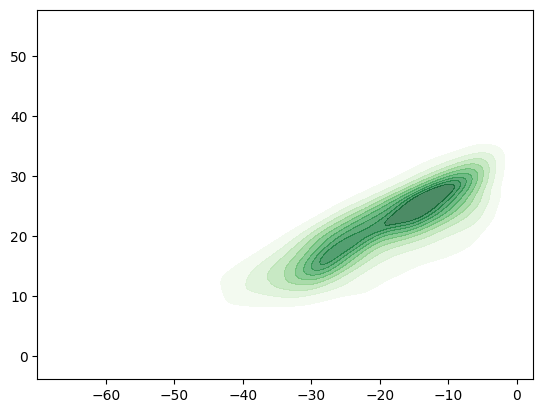

In [43]:
import seaborn as sns
sns.kdeplot(x=result_df['deltaG(kcal/mol)'].to_numpy(), y=result_df['deltaGa(kcal/mol)'].to_numpy(), cmap="Greens", shade=True, bw_adjust=1, thresh=0.1, alpha=0.7)

Text(0, 0.5, 'deltaGa(kcal/mol)')

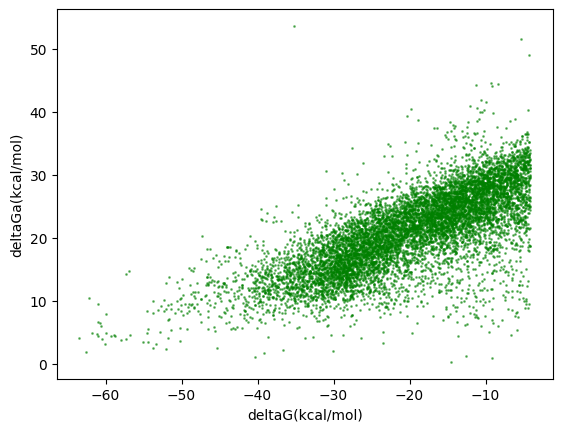

In [40]:
# for Cl_index in result_df['B_Index'].unique():
#     color = np.random.rand(3,)
#     temp_df = result_df[result_df['B_Index'] == Cl_index]
plt.scatter(result_df['deltaG(kcal/mol)'], result_df['deltaGa(kcal/mol)'], c='green', s=1, alpha=0.5)
# plt.scatter(result_df['deltaG(kcal/mol)'], result_df['deltaGa(kcal/mol)'], c=color, s=1)
plt.xlabel('deltaG(kcal/mol)')
plt.ylabel('deltaGa(kcal/mol)')
# plt.show()

In [ ]:
log_files = glob.glob(r"E:\work\B_Cl_Nu\Sum\TS_uncertain_IRC\*.log")
type_a = []
type_b = []
for log_file in log_files:
    if 'reverse' in log_file or 'forward' in log_file:
        continue
    new_log = None
    for direct in ['forward', 'reverse']:
        new_log = os.path.basename(log_file).replace('.log', f'{direct}')
        if len(glob.glob(rf'E:\work\B_Cl_Nu\Sum\Combine_Reactant\{new_log}*.log')) == 0:
            break
    new_log = logfile_process.Logfile(log_file.replace('.log', f'{direct}.log'))
    title = [each - 1 for each in new_log.title]
    distance_1 = Tool.get_atoms_distance(new_log.running_positions[-1][title[0]], new_log.running_positions[-1][title[1]])
    distance_2 = Tool.get_atoms_distance(new_log.running_positions[-1][title[1]], new_log.running_positions[-1][title[2]])
    if distance_1 < 2.2:
        type_a.append(log_file)
    if distance_2 < 2.1:
        type_b.append(log_file)

In [119]:
type_c = set(type_a) & set(type_b)
type_a_ = set(type_a) - set(type_c)
type_b_ = set(type_b) - set(type_c)

In [141]:
type_a_dict = []
for log_file in type_a_:
    names = os.path.basename(log_file).split('reverse')[0].split('forward')[0].split('.')[0].split('_')
    B_index, N_index, Cl_index = [int(each) for each in names[1:6:2]]
    type_a_dict.append([B_index, N_index, Cl_index])
type_b_dict = []
for log_file in type_b_:
    names = os.path.basename(log_file).split('reverse')[0].split('forward')[0].split('.')[0].split('_')
    B_index, N_index, Cl_index = [int(each) for each in names[1:6:2]]
    type_b_dict.append([B_index, N_index, Cl_index])
react_dG = []
for log_file in glob.glob('E:\work\B_Cl_Nu\Sum\Combine_Reactant\*.log'):
    names = os.path.basename(log_file).split('reverse')[0].split('forward')[0].split('.')[0].split('_')
    B_index, N_index, Cl_index = [int(each) for each in names[1:6:2]]
    log = logfile_process.Logfile(log_file)
    eng_file = log_file.replace('Combine_Reactant', 'Combine_Reactant_eng')
    eng = logfile_process.Logfile(eng_file)
    Reactant_G = log.all_engs[-1] + eng.all_engs[-1]
    # if [B_index, N_index, Cl_index] in type_a_dict:
    base_G = BN_energies_r[f'{B_index:05}_{N_index:05}'] + Cl_energies_r[f'{Cl_index:05}']
    # else:
    #     base_G = BN_energies_p[f'{B_index:05}_{N_index:05}'] + Cl_energies_p[f'{Cl_index:05}']
    react_dG.append(627.5*(Reactant_G - base_G))

E:\work\B_Cl_Nu\Sum\Combine_Reactant_eng\B_00392_Nu_00138_Cl_00485_0000forward3.log didn't run successful


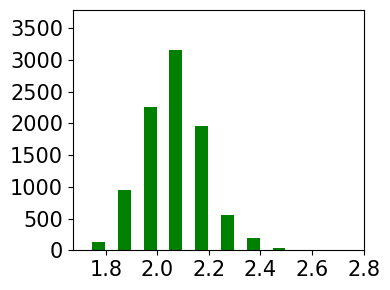

array([ 130,  951, 2264, 3154, 1950,  562,  188,   36,    1,    1,    0])

In [45]:
B_N_Cl.calc_distribution2(result_df['C_Cl'], 0.1, ylab="")

In [31]:
result_df

,B_Index,N_Index,Cl_Index,Conf_id,TS_G,deltaG(kcal/mol),deltaGa(kcal/mol),B_Cl,C_Cl
0,388.0,0.0,500.0,12.0,-1029.592007,-33.510445,15.690129,2.944906,2.113243
1,388.0,1.0,466.0,13.0,-1524.923417,-41.280903,9.890297,3.349939,1.824952
2,388.0,1.0,474.0,10.0,-1054.806112,-23.956318,12.493770,2.616410,1.857636
3,388.0,1.0,475.0,2.0,-777.803722,-28.161070,14.914297,2.588579,1.931784
4,388.0,1.0,476.0,0.0,-815.874915,-38.631536,14.312536,2.711785,1.897374
...,...,...,...,...,...,...,...,...,...
10644,442.0,272.0,602.0,0.0,-2520.728953,-24.757134,17.981878,2.846897,2.010831
10646,442.0,297.0,502.0,1.0,-1381.294546,-18.174784,24.165471,2.834315,2.169484
10648,442.0,303.0,536.0,1.0,-1850.933732,-23.827807,14.579379,3.047694,2.024979
10653,442.0,343.0,522.0,1.0,-1595.466594,-23.538215,18.560258,3.054054,2.011534


In [126]:
type_a_energies

[2253.8524896,
 2114.927206,
 1211.4503847,
 2388.3661500000003,
 2495.39271,
 1726.3889214,
 2196.7909107,
 1671.357563,
 1689.5744854000002,
 1841.0334658,
 1905.7956078000002,
 1830.5751321,
 1334.3865567,
 1902.6708758,
 2134.197835,
 1884.1887794000002,
 2206.8905517999997,
 1806.4883489000001,
 2145.4759354000003,
 1261.4324106000001,
 1978.3532142,
 1710.1777165,
 1728.910622,
 2264.8729586,
 1787.8257786000001,
 1938.7527844,
 2071.3300565,
 1436.5374104999999,
 1848.0305207000001,
 3039.2385510000004,
 3331.759709,
 1884.6782361,
 1748.7735006,
 1768.248881,
 1157.5388322000001,
 1586.5843714000002,
 1625.9145675,
 2615.028954,
 1692.9122558000001,
 1393.3676546,
 1799.4395814000002,
 2208.1926966,
 2536.143128,
 3448.5439899999997,
 1828.2800292,
 1645.2757267000002,
 3156.04282,
 2255.8079264000003,
 1413.1792264,
 2381.2353260000004,
 2346.1523840000004,
 1962.3881385000002,
 2189.3423728000002,
 1298.5866516999997,
 1688.3624332000002,
 3214.956108]